<details>
   <summary><b>Table of Contents</b></summary>

   - [1. Review Data](#1-review-data)
   - [2. Train - Test Split](#2-train---test-split)
   - [3. Model Selection](#3-model-selection)
   - [4. Test with Best Model](#4-test-with-best-model)
   - [5. Tuning Model](#5-tuning-model)
   - [6. Evaluate Model](#6-evaluate-model)
     - [6.1. Train - Test Split](#61-train---test-split)
     - [6.2. Cross Validation (K-Fold)](#62-cross-validation-k-fold)
     - [6.3. Visualization](#63-visualization)
   - [7. Save Model](#7-save-model)
</details>

In [1]:
import os
import ast
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.float_format', lambda x: f'{x:.3e}')

## **1. Review Data**
---

In [2]:
df = pd.read_csv('../data/data_model.csv')
df.head()

,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,job_simplified,seniority,Rating Category,job_state,Python_yn,Spark,AWS_yn,Average Salary
0,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),data scientist,Other,Medium Rating,NM,1,0,0,7.200e+04
1,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+ employees,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),data scientist,Other,Medium Rating,MD,1,0,0,8.750e+04
2,KnowBe4,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,Company - Private,Security Services,Business Services,$100 to $500 million (USD),data scientist,Other,High Rating,FL,1,1,0,8.500e+04
3,PNNL,"Richland, WA","Richland, WA",1001 to 5000 employees,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),data scientist,Other,Medium Rating,WA,1,0,0,7.650e+04
4,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,Company - Private,Advertising & Marketing,Business Services,Unknown,data scientist,Other,Low Rating,NY,1,0,0,1.145e+05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company Name       742 non-null    object 
 1   Location           742 non-null    object 
 2   Headquarters       742 non-null    object 
 3   Size               742 non-null    object 
 4   Type of ownership  742 non-null    object 
 5   Industry           742 non-null    object 
 6   Sector             742 non-null    object 
 7   Revenue            742 non-null    object 
 8   job_simplified     742 non-null    object 
 9   seniority          742 non-null    object 
 10  Rating Category    742 non-null    object 
 11  job_state          742 non-null    object 
 12  Python_yn          742 non-null    int64  
 13  Spark              742 non-null    int64  
 14  AWS_yn             742 non-null    int64  
 15  Average Salary     742 non-null    float64
dtypes: float64(1), int64(3), o

In [4]:
df.describe()

,Python_yn,Spark,AWS_yn,Average Salary
count,7.420e+02,7.420e+02,7.420e+02,7.420e+02
mean,5.283e-01,2.251e-01,2.372e-01,1.015e+05
std,4.995e-01,4.179e-01,4.257e-01,3.746e+04
min,0.000e+00,0.000e+00,0.000e+00,1.550e+04
25%,0.000e+00,0.000e+00,0.000e+00,7.350e+04
50%,1.000e+00,0.000e+00,0.000e+00,9.750e+04
75%,1.000e+00,0.000e+00,0.000e+00,1.225e+05
max,1.000e+00,1.000e+00,1.000e+00,2.540e+05


## **2. Train - Test Split**
---

In [5]:
X = df.drop('Average Salary', axis=1)
y = df['Average Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")

X_train shape: (593, 15)
y_train shape: (593,)
X_test  shape: (149, 15)
y_test  shape: (149,)


## **3. Model Selection**
---

In [6]:
def create_regression_pipeline(model_name):
    regression_models = {
        'SVR'                      : SVR(),
        'XGBoost'                  : XGBRegressor(random_state=42),
        'KNeighbors'               : KNeighborsRegressor(),
        'DecisionTree'             : DecisionTreeRegressor(random_state=42),
        'RandomForest'             : RandomForestRegressor(random_state=42),
        'LinearRegression'         : LinearRegression(),
        'HistogramGradientBoosting': HistGradientBoostingRegressor(random_state=42),
    }

    categorical_features = X.select_dtypes(include=['object']).columns.tolist()
    numerical_features   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ]
    )

    regression_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regression_models[model_name])
    ])

    pipeline_dict = {model_name: regression_pipeline}
    return pipeline_dict

def create_all_regression_pipelines():
    regression_model_names = ['RandomForest', 'SVR', 'LinearRegression', 'KNeighbors', 'DecisionTree', 'XGBoost', 'HistogramGradientBoosting']

    all_pipelines = {}
    for model_name in regression_model_names:
        pipeline_dict = create_regression_pipeline(model_name)
        all_pipelines.update(pipeline_dict)
        
    return all_pipelines

def train_evaluate_model_with_df(model_name, model, X_train, y_train, X_test, y_test, results_df):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    model_results = pd.DataFrame({'Model': [model_name], 'MSE': mse, 'MAE': mae, 'R2': r2})
    results_df = pd.concat([results_df, model_results], ignore_index=True)
    return results_df

def run_pipelines_with_metrics_to_dataframe(all_pipelines, X_train, y_train, X_test, y_test):
    results_df = pd.DataFrame(columns=['Model', 'MSE', 'MAE', 'R2'])

    for model_name, pipeline in all_pipelines.items():
        results_df = train_evaluate_model_with_df(
            model_name, pipeline, 
            X_train, y_train, X_test, y_test, 
            results_df
        )

    results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
    return results_df

In [7]:
all_pipelines = create_all_regression_pipelines()
results_df    = run_pipelines_with_metrics_to_dataframe(all_pipelines, X_train, y_train, X_test, y_test)
results_df

,Model,MSE,MAE,R2
0,XGBoost,2.896e+08,1.056e+04,8.153e-01
1,RandomForest,2.936e+08,1.127e+04,8.127e-01
2,HistogramGradientBoosting,4.009e+08,1.456e+04,7.443e-01
3,DecisionTree,4.605e+08,1.024e+04,7.062e-01
4,LinearRegression,4.624e+08,1.212e+04,7.050e-01
5,KNeighbors,8.030e+08,2.114e+04,4.878e-01
6,SVR,1.616e+09,3.117e+04,-3.078e-02


**Observations**:

Best-performing models:

- **XGBoost** has the lowest MSE (2.896e+08) and MAE (1.056e+04) with the highest R² (0.8153), making it the top performer.
- **Random Forest** follows closely with similar MSE and MAE but slightly lower R² (0.8127).

Moderate performance:

- **Histogram Gradient Boosting**, **Decision Tree**, and **Linear Regression** show decent results but with higher errors and lower R² scores (~0.70).

Poor performance:

- **K-Neighbors** has significantly higher MSE (8.030e+08) and MAE (2.114e+04), leading to a poor R² (0.4878).
- **SVR** performs worst, with extremely high MSE (1.616e+09) and MAE (3.117e+04), and a negative R² (-0.0378), indicating it fails to explain variance.

**Conclusion**:

- **XGBoost** is the best model, offering the best balance of error minimization and predictive power.
- **Random Forest** is a strong alternative, with only a slight drop in performance.
- **SVR** and **K-Neighbors** are ineffective for this dataset and should be avoided.

## **4. Test with Best Model**
---

In [8]:
xgb_res        = XGBRegressor()
default_params = xgb_res.get_params()

desired_params          = ['reg_lambda', 'reg_alpha', 'n_estimators', 'max_depth', 'learning_rate', 'gamma', 'colsample_bytree']
selected_default_params = {param: default_params[param] for param in desired_params}

default_params_df = pd.DataFrame([selected_default_params])
default_params_df = default_params_df.transpose()
default_params_df.columns = ['Value']

print("XGBRegressor default params:")
default_params_df.T

XGBRegressor default params:


,reg_lambda,reg_alpha,n_estimators,max_depth,learning_rate,gamma,colsample_bytree
Value,None,None,None,None,None,None,None


In [9]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

xgb_res = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor())
])

xgb_res.fit(X_train, y_train)
y_pred = xgb_res.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2 : {r2:.3f}")

MSE: 289622501.735
MAE: 10560.083
R2 : 0.815


## **5. Tuning Model**
---

In [10]:
params = {
    "n_estimators"    : range(100, 500, 50),
    "learning_rate"   : [0.0001, 0.001, 0.01, 0.1, 1],
    "max_depth"       : range(3, 21, 3),
    "gamma"           : [i / 10.0 for i in range(0, 5)],
    "colsample_bytree": [i / 10.0 for i in range(3, 10)],
    "reg_alpha"       : [1e-5, 1e-2, 0.1, 1, 10, 100],
    "reg_lambda"      : [1e-5, 1e-2, 0.1, 1, 10, 100]
}

rs = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',RandomizedSearchCV(XGBRegressor(),params,n_iter=50,verbose=3,random_state=42))
])
rs.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.016 total time=   0.5s
[CV 2/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.029 total time=   0.4s
[CV 3/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.005 total time=   0.4s
[CV 4/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.029 total time=   0.4s
[CV 5/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.029 total time=   0.4s
[CV 1/5] END colsample_bytree=0.6, gamma=0.1, learning_rate=1, max_depth=18, n_estimators=450, reg_alpha=1, reg_lambda=100;, sco

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Python_yn', 'Spark',
                                                   'AWS_yn']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Company Name', 'Location',
                                                   'Headquarters', 'Size',
                                                   'Type of ownership',
                                                   'Industry', 'Sector',
                                                   'Revenue', 'job_simplified',
                                                   'seniority',
                                                   'Rating Category',
                                                   'job_state'])])),
                ('mod...
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...),
                                    n_iter=50,
                                    param_distributions={'colsample_bytree': [0.3,
                                                                              0.4,
                                                                              0.5,
                                                                              0.6,
                                                                              0.7,
                                                                              0.8,
                                                                              0.9],
                                                         'gamma': [0.0, 0.1,
                                                                   0.2, 0.3,
                                                                   0.4],
                                                         'learning_rate': [0.0001,
                                                                           0.001,
                                                                           0.01,
                                                                           0.1,
                                                                           1],
                                                         'max_depth': range(3, 21, 3),
                                                         'n_estimators': range(100, 500, 50),
                                                         'reg_alpha': [1e-05,
                                                                       0.01,
                                                                       0.1, 1,
                                                                       10,
                                                                       100],
                                                         'reg_lambda': [1e-05,
                                                                        0.01,
                                                                        0.1, 1,
                                                                        10,
                                                                        100]},
                                    random_state=42, verbose=3))])

In [11]:
random_search = rs.named_steps['model']
print(f'Best score: {random_search.best_score_:.3f}')

best_params_df = pd.DataFrame([random_search.best_params_]).transpose()
best_params_df.columns = ['Value']
print('Best params:')
best_params_df.T

Best score: 0.729
Best params:


,reg_lambda,reg_alpha,n_estimators,max_depth,learning_rate,gamma,colsample_bytree
Value,1.000e-05,1.000e+00,4.500e+02,1.800e+01,1.000e-01,4.000e-01,4.000e-01


In [12]:
random_search = rs.named_steps['model']
results_df = pd.DataFrame(random_search.cv_results_)

selected_columns = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
results_df = results_df[selected_columns]

results_df = results_df.sort_values(by='rank_test_score')

output_dir = '../model/tuning'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_path = os.path.join(output_dir, 'RandomSearch_CV_XGBoost_OneHot.csv')
results_df.to_csv(output_path, index=False)

## **6. Evaluate Model**
---

### **6.1. Train - Test Split**

In [13]:
xgb_rscv = pd.read_csv("../model/tuning/RandomSearch_CV_XGBoost_OneHot.csv")
best_params = ast.literal_eval(xgb_rscv['params'][0])

xgb_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',XGBRegressor(**best_params))
])

xgb_best.fit(X_train, y_train)
y_pred = xgb_best.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2 : {r2:.3f}")

MSE: 295360220.488
MAE: 7959.197
R2 : 0.812


### **6.2. Cross Validation (K-Fold)**

In [14]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mses = []
maes = []
r2s = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i + 1}:") 

    xgb_best.fit(X.iloc[train_index], y.iloc[train_index])
    y_pred = xgb_best.predict(X.iloc[test_index])

    mse = mean_squared_error(y.iloc[test_index], y_pred)
    mae = mean_absolute_error(y.iloc[test_index], y_pred)
    r2 = r2_score(y.iloc[test_index], y_pred)

    print(f"Mean Squared Error (MSE): {mse:.3f}")
    print(f"Mean Absolute Error (MAE): {mae:.3f}")
    print(f"R-squared (R2) Score: {r2:.3f}")
    print()

    mses.append(mse)
    maes.append(mae)
    r2s.append(r2)

mean_mse = sum(mses) / len(mses)
mean_mae = sum(maes) / len(maes)
mean_r2 = sum(r2s) / len(r2s)

print(f"Mean MSEs: {mean_mse:.3f}")
print(f"Mean MAEs: {mean_mae:.3f}")
print(f"Mean R2s: {mean_r2:.3f}")

Fold 1:
Mean Squared Error (MSE): 267974812.374
Mean Absolute Error (MAE): 7943.500
R-squared (R2) Score: 0.830

Fold 2:
Mean Squared Error (MSE): 287742068.865
Mean Absolute Error (MAE): 6884.293
R-squared (R2) Score: 0.805

Fold 3:
Mean Squared Error (MSE): 277601300.095
Mean Absolute Error (MAE): 7694.023
R-squared (R2) Score: 0.706

Fold 4:
Mean Squared Error (MSE): 294487960.058
Mean Absolute Error (MAE): 7348.485
R-squared (R2) Score: 0.817

Fold 5:
Mean Squared Error (MSE): 220686432.417
Mean Absolute Error (MAE): 7375.173
R-squared (R2) Score: 0.800

Fold 6:
Mean Squared Error (MSE): 169371102.556
Mean Absolute Error (MAE): 6499.659
R-squared (R2) Score: 0.906

Fold 7:
Mean Squared Error (MSE): 559648656.920
Mean Absolute Error (MAE): 10111.290
R-squared (R2) Score: 0.604

Fold 8:
Mean Squared Error (MSE): 233159459.665
Mean Absolute Error (MAE): 6821.342
R-squared (R2) Score: 0.807

Fold 9:
Mean Squared Error (MSE): 379988695.625
Mean Absolute Error (MAE): 9807.622
R-squared (

### **6.3. Visualization**

In [15]:
def plot_metric_scores(metric_values, metric_name):
    plt.figure(figsize=(8, 6))
    plt.bar(range(1, len(metric_values) + 1), metric_values, color='skyblue')
    plt.xlabel('Fold')
    plt.xticks(range(1, len(metric_values) + 1))
    plt.show()

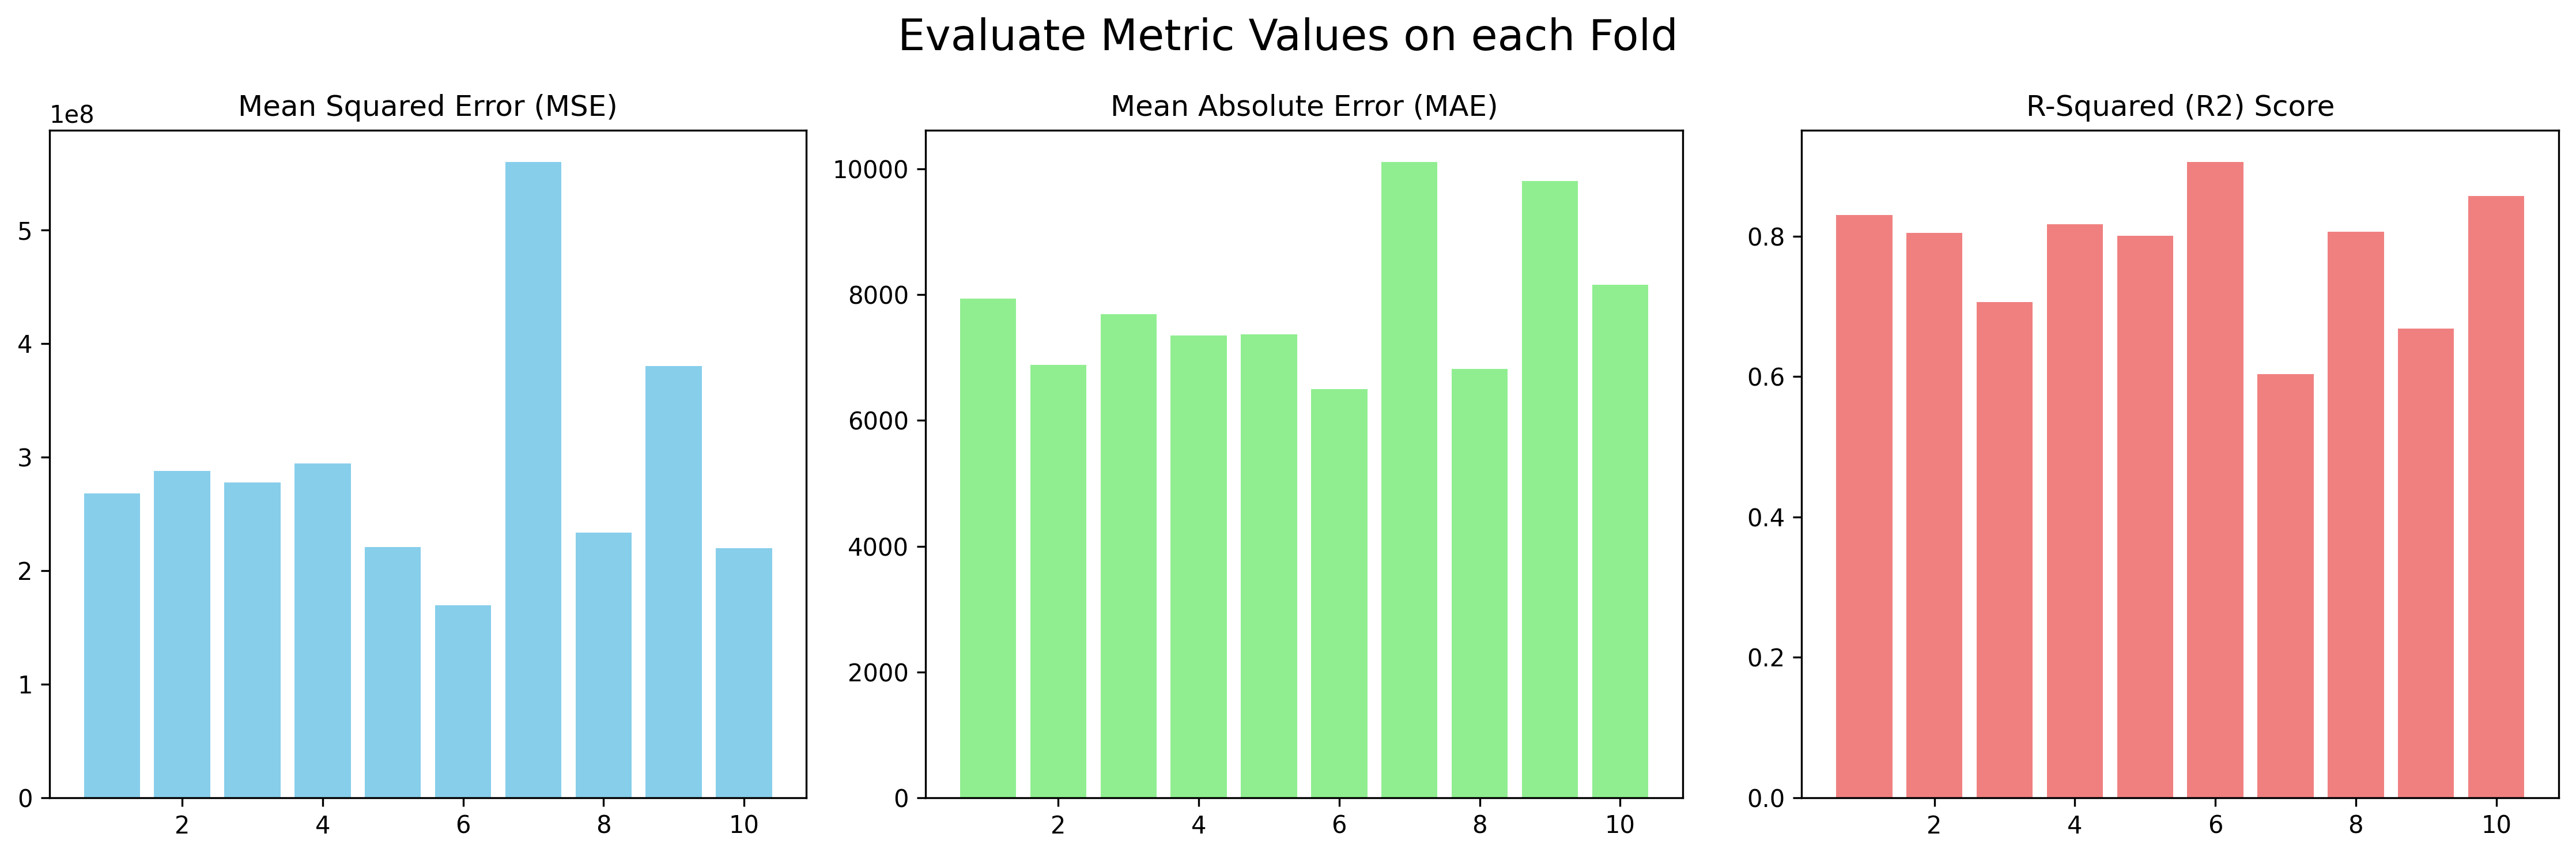

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), dpi=300)

axes[0].bar(range(1, len(mses) + 1), mses, color='skyblue')
axes[0].set_title('Mean Squared Error (MSE)')

axes[1].bar(range(1, len(maes) + 1), maes, color='lightgreen')
axes[1].set_title('Mean Absolute Error (MAE)')

axes[2].bar(range(1, len(r2s) + 1), r2s, color='lightcoral')
axes[2].set_title('R-Squared (R2) Score')

fig.suptitle("Evaluate Metric Values on each Fold", fontsize=18)
plt.tight_layout()
plt.show()

## **7. Save Model**
---

In [17]:
import joblib

joblib.dump(xgb_best, "../model/xgb_salary_predictor.pkl")
print("Model Saved!")

Model Saved!
